# Pendulum 1 Period Test Analysis

This notebook loads a `pendulum 1_period_test_*.csv` capture, plots the angle trace, estimates the oscillation period from successive positive peaks, and computes the simple-pendulum effective length

$$l = g\left(\frac{T}{2\pi}\right)^2$$

using the average measured period.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

G_M_S2 = 9.81

# Set to a filename such as "pendulum 1_period_test_20260419_153000.csv",
# or leave as None to use the newest pendulum 1 period-test capture.
DATA_PATH = None

cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents]
repo_root = next((candidate for candidate in search_roots if (candidate / ".git").exists()), None)
if repo_root is None:
    repo_root = next((candidate for candidate in search_roots if (candidate / "hardware").exists()), cwd)

captures_dir = repo_root / "hardware" / "magnetic encoder" / "captures"
if DATA_PATH is None:
    candidates = sorted(captures_dir.glob("pendulum 1_period_test_*.csv"))
    if not candidates:
        raise FileNotFoundError(f"No pendulum 1 period-test CSV files found in {captures_dir}")
    path = candidates[-1]
else:
    path = captures_dir / DATA_PATH

if not path.exists():
    raise FileNotFoundError(f"Could not find period-test CSV: {path}")

path

WindowsPath('C:/Users/Nathan/My Drive/Personal/Graduate School/ASE 381P3 Optimal Control - Bakolas/pendulum/hardware/magnetic encoder/captures/pendulum 1_period_test_20260419_093442.csv')

In [8]:
df = pd.read_csv(path)

numeric_columns = ["host_timestamp_s", "time_ms", "theta_deg", "theta_rad", "omega_rad_s"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna(subset=["theta_rad"]).copy()

encoder_time_s = (df["time_ms"] - df["time_ms"].iloc[0]) / 1000.0
host_time_s = df["host_timestamp_s"] - df["host_timestamp_s"].iloc[0]

if np.all(np.diff(encoder_time_s) >= 0):
    df["time_s"] = encoder_time_s
    time_source = "encoder time_ms"
else:
    df["time_s"] = host_time_s
    time_source = "host_timestamp_s"

window = 5
df["theta_smooth_rad"] = (
    df["theta_rad"]
    .rolling(window=window, center=True, min_periods=1)
    .mean()
)

df[["time_s", "theta_rad", "theta_smooth_rad", "omega_rad_s"]].head()

,time_s,theta_rad,theta_smooth_rad,omega_rad_s
0,0.00,-0.001534,-0.003068,-0.153398
1,0.01,-0.004602,-0.002301,-0.306796
2,0.02,-0.003068,-0.001841,0.153398
3,0.03,0.000000,-0.001534,0.306796
4,0.04,0.000000,-0.000307,0.000000


In [9]:
theta = df["theta_smooth_rad"].to_numpy()
time_s = df["time_s"].to_numpy()

# Extrema-picking knobs for small-angle free-swing data.
# Lower PEAK_THRESHOLD_MIN_DEG if the oscillation amplitude is tiny.
# MIN_EXTREMA_DISTANCE_S suppresses duplicate picks from encoder quantization.
PEAK_THRESHOLD_FRACTION = 0.10
PEAK_THRESHOLD_MIN_DEG = 0.05
MIN_EXTREMA_DISTANCE_S = 0.3

theta_center_rad = float(np.mean(theta))
theta_centered = theta - theta_center_rad
amplitude_rad = float(np.nanmax(np.abs(theta_centered)))
peak_threshold_rad = max(PEAK_THRESHOLD_FRACTION * amplitude_rad, np.deg2rad(PEAK_THRESHOLD_MIN_DEG))

dt = np.median(np.diff(time_s))
min_extrema_distance = max(1, int(round(MIN_EXTREMA_DISTANCE_S / max(dt, 1e-6))))

maxima_indices = []
minima_indices = []
last_max_index = -min_extrema_distance
last_min_index = -min_extrema_distance

for idx in range(1, len(theta_centered) - 1):
    value = theta_centered[idx]
    is_local_max = theta_centered[idx - 1] < value and value >= theta_centered[idx + 1]
    is_local_min = theta_centered[idx - 1] > value and value <= theta_centered[idx + 1]

    if is_local_max and value >= peak_threshold_rad and (idx - last_max_index) >= min_extrema_distance:
        maxima_indices.append(idx)
        last_max_index = idx

    if is_local_min and value <= -peak_threshold_rad and (idx - last_min_index) >= min_extrema_distance:
        minima_indices.append(idx)
        last_min_index = idx

maxima_times_s = time_s[maxima_indices]
minima_times_s = time_s[minima_indices]
periods_from_maxima_s = np.diff(maxima_times_s)
periods_from_minima_s = np.diff(minima_times_s)
periods_s = np.concatenate([periods_from_maxima_s, periods_from_minima_s])
periods_s = np.sort(periods_s)

if len(periods_s) < 1:
    raise RuntimeError(
        "Not enough same-sign extrema were found to estimate the full period. "
        "Try a cleaner free-swing capture or lower PEAK_THRESHOLD_MIN_DEG or PEAK_THRESHOLD_FRACTION."
    )

average_period_s = float(np.mean(periods_s))
period_std_s = float(np.std(periods_s, ddof=1)) if len(periods_s) > 1 else 0.0
estimated_length_m = G_M_S2 * (average_period_s / (2.0 * np.pi)) ** 2

summary = pd.Series(
    {
        "file": path.name,
        "samples": int(len(df)),
        "time_source": time_source,
        "duration_s": float(time_s[-1] - time_s[0]),
        "max_abs_theta_deg": float(np.rad2deg(amplitude_rad)),
        "theta_center_rad": theta_center_rad,
        "positive_extrema_used": int(len(maxima_indices)),
        "negative_extrema_used": int(len(minima_indices)),
        "individual_periods_from_maxima_s": np.round(periods_from_maxima_s, 4).tolist(),
        "individual_periods_from_minima_s": np.round(periods_from_minima_s, 4).tolist(),
        "individual_periods_s": np.round(periods_s, 4).tolist(),
        "average_period_s": average_period_s,
        "period_std_s": period_std_s,
        "estimated_l_m": estimated_length_m,
        "estimated_l_mm": 1000.0 * estimated_length_m,
    }
)

summary

RuntimeError: Not enough positive peaks were found to estimate the period. Try a cleaner free-swing capture or lower peak_threshold_rad.

NameError: name 'periods_s' is not defined

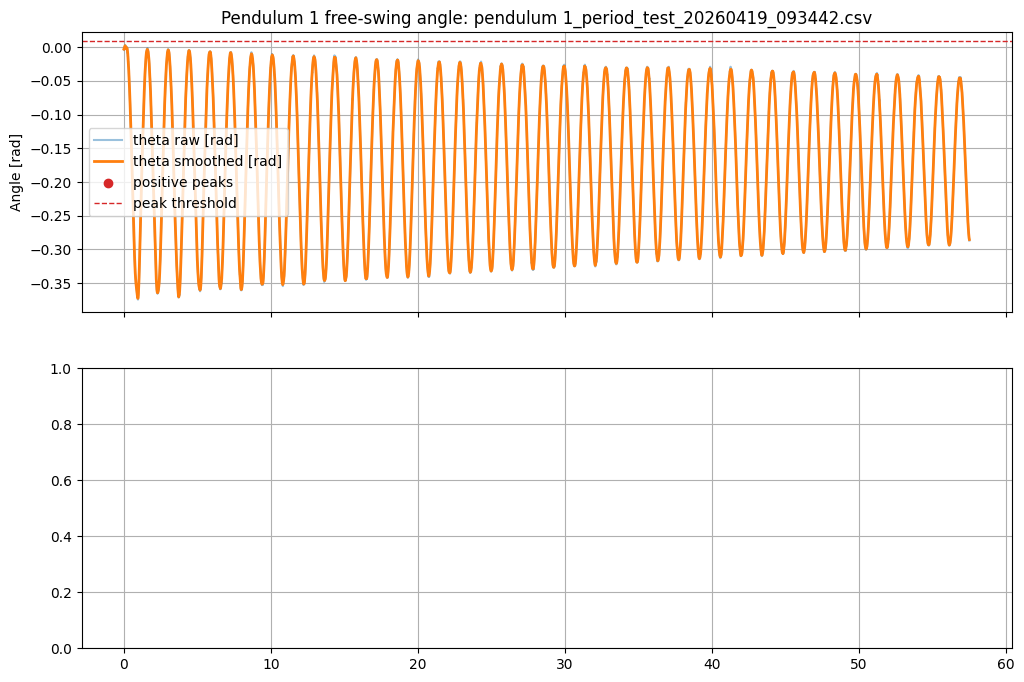

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time_s"], df["theta_rad"], label="theta raw [rad]", alpha=0.4)
axes[0].plot(df["time_s"], df["theta_smooth_rad"], label="theta smoothed [rad]", linewidth=2)
axes[0].axhline(theta_center_rad, color="tab:green", linestyle="--", linewidth=1, label="mean angle")
axes[0].scatter(time_s[maxima_indices], theta[maxima_indices], color="tab:red", s=20, label="positive extrema", zorder=3)
axes[0].scatter(time_s[minima_indices], theta[minima_indices], color="tab:purple", s=20, label="negative extrema", zorder=3)
axes[0].axhline(theta_center_rad + peak_threshold_rad, color="tab:red", linestyle="--", linewidth=1, alpha=0.7, label="threshold band")
axes[0].axhline(theta_center_rad - peak_threshold_rad, color="tab:red", linestyle="--", linewidth=1, alpha=0.7)
axes[0].set_ylabel("Angle [rad]")
axes[0].set_title(f"Pendulum 1 free-swing angle: {path.name}")
axes[0].legend()

axes[1].plot(np.arange(1, len(periods_s) + 1), periods_s, marker="o")
axes[1].axhline(average_period_s, color="tab:green", linestyle="--", label=f"average full period = {average_period_s:.4f} s")
axes[1].set_xlabel("Same-sign extrema interval index")
axes[1].set_ylabel("Full period [s]")
axes[1].set_title(f"Estimated l = {estimated_length_m:.4f} m ({1000.0 * estimated_length_m:.1f} mm)")
axes[1].legend()

plt.tight_layout()
plt.show()